# Segmentación pulmonar

Entrenamiento y evaluación de las redes de segmentación pulmonar del proyecto.

El objetivo del proyecto no es obtener el mejor segmentador, sino **medir si la técnica de segmentación cambia las características radiómicas y el desempeño de los modelos de detección de tuberculosis**. La segmentación es un paso intermedio: todas las técnicas que pasen el control de calidad continúan a la extracción con pyradiomics. De ahí dos exigencias:

- Todas las técnicas se entrenan y evalúan **en igualdad de condiciones**, para que las diferencias posteriores se atribuyan a la técnica y no al protocolo.
- Agregar una técnica nueva no debe obligar a rehacer las etapas siguientes.

**Estado de este notebook:** por ahora solo U-Net. Attention U-Net y MedSAM se agregarán después, con la misma rutina.

| Sección | Contenido |
|---|---|
| 1 | Configuración común a todas las corridas |
| 2 | Datos de entrenamiento (Montgomery + Shenzhen) |
| 3 | Arquitecturas |
| 4 | Entrenamiento |
| 5 | Curvas de aprendizaje |
| 6 | Calidad de la segmentación en el conjunto de prueba |
| 7+ | Siguientes pasos (pendientes) |

## 1. Configuración común

Los parámetros viven en `src/tbseg/segmentation/train.py` y se importan aquí, para que el notebook muestre **los valores que realmente se usaron** y no una copia que puede quedar desactualizada.

Entre corridas solo cambian dos cosas: la **arquitectura** y la **semilla**. Todo lo demás (datos, partición, aumentos, pérdida, optimizador, épocas) es idéntico.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tbseg.config import IMAGE_SIZE, RESULTS_DIR, SEGTRAIN_CSV, SEGTRAIN_DIR
from tbseg.segmentation import train as T

SEG_RESULTS_DIR = RESULTS_DIR / "segmentation"
SEEDS = [42, 43, 44]

config = pd.Series({
    "Resolución": f"{IMAGE_SIZE}×{IMAGE_SIZE}",
    "Tamaño de lote": T.BATCH_SIZE,
    "Optimizador": f"Adam (lr={T.LEARNING_RATE})",
    "Pérdida": "BCE + Dice",
    "Épocas máximas": T.MAX_EPOCHS,
    "Detención temprana": f"{T.PATIENCE} épocas sin mejorar el Dice de validación",
    "Canales por nivel": str(T.CHANNELS),
    "Umbral de binarización": T.THRESHOLD,
    "Semillas": ", ".join(map(str, SEEDS)),
}).to_frame("valor")
config.index.name = "parámetro"
display(config)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
C_TRUE, C_PRED = "#2a78d6", "#eb6834"   # azul: máscara real | naranja: predicción

/home/julian/proyects/tuberculosis-lung-segmentation/.venv/lib/python3.10/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(


,valor
parámetro,
Resolución,512×512
Tamaño de lote,8
Optimizador,Adam (lr=0.001)
Pérdida,BCE + Dice
Épocas máximas,60
Detención temprana,10 épocas sin mejorar el Dice de validación
Canales por nivel,"(16, 32, 64, 128, 256)"
Umbral de binarización,0.5
Semillas,"42, 43, 44"


**Aumento de datos** (solo en entrenamiento, definido en `train.augment`): rotación ±10°, escala 0.9–1.1, traslación hasta 5 % y cambios de brillo y contraste (±20 % y ±0.1). Las transformaciones geométricas se aplican **igual a la imagen y a su máscara**; las de intensidad, solo a la imagen.

Cada rango imita una variación que ocurre entre radiografías reales: la inclinación del paciente frente al detector (rotación), su distancia y contextura (escala), el encuadre del técnico (traslación) y la exposición del equipo (brillo y contraste). Son rangos pequeños a propósito: una radiografía de tórax es una proyección estandarizada, así que deformarla más generaría imágenes que no existen en la práctica. **No se usa volteo horizontal** porque pondría el corazón a la derecha.

La práctica viene del artículo original de U-Net, que entrenaba con pocas imágenes y usaba desplazamiento, rotación y deformaciones elásticas, y es estándar en segmentación pulmonar en radiografía: rotación, traslación y escala aparecen de forma sistemática en los trabajos sobre Montgomery y Shenzhen.

## 2. Datos de entrenamiento

TBX11K no tiene máscaras de pulmón, así que las redes se entrenan con **Montgomery + Shenzhen**: 704 radiografías con máscaras trazadas manualmente bajo supervisión de radiólogos. `python -m tbseg.segmentation.prepare` ya las dejó a 512×512 y escribió la partición en `data/metadata/segtrain_split.csv`.

- **train (70 %)**: con lo que la red aprende.
- **val (15 %)**: vigila el entrenamiento, decide la detención temprana y selecciona la mejor época.
- **test (15 %)**: se usa **una sola vez**, al final, para reportar el desempeño.

La partición está estratificada por origen (Montgomery/Shenzhen) y diagnóstico (sano/TB), y es **la misma para todas las corridas**.

split            test  train  val  total
source     tb                           
montgomery TB       9     40    9     58
           sano    12     56   12     80
shenzhen   TB      43    201   43    287
           sano    42    195   42    279
total             106    492  106    704

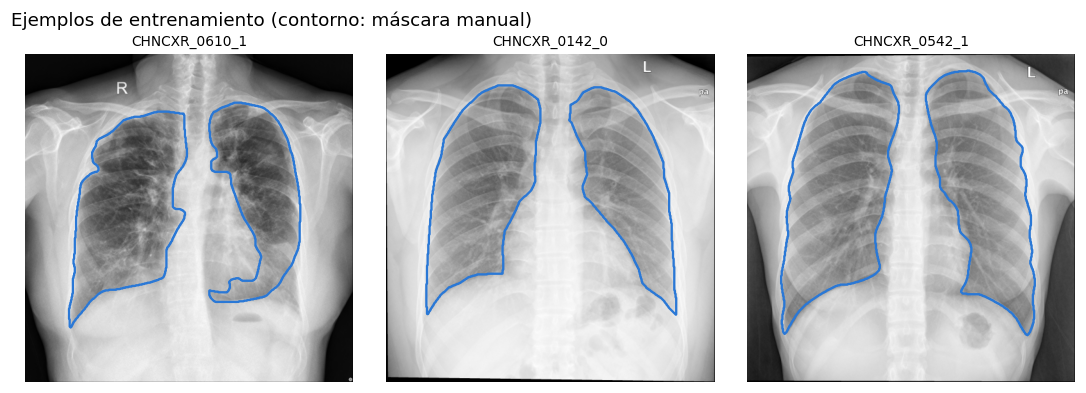

In [2]:
split = pd.read_csv(SEGTRAIN_CSV)
display(pd.crosstab([split["source"], split["tb"].map({0: "sano", 1: "TB"})], split["split"],
                    margins=True, margins_name="total"))

ids = split[split["split"] == "train"].sample(3, random_state=0)["image_id"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, image_id in zip(axes, ids):
    img, mask = T.load_pair(image_id)
    ax.imshow(img, cmap="gray"); ax.contour(mask, levels=[0.5], colors=C_TRUE, linewidths=1.5)
    ax.set_title(image_id, fontsize=9); ax.axis("off")
fig.suptitle("Ejemplos de entrenamiento (contorno: máscara manual)", x=0.01, ha="left")
fig.tight_layout()
plt.show()

## 3. Arquitecturas

Se usan las implementaciones de **MONAI**, una librería especializada en imagen médica, con los mismos argumentos para todas las arquitecturas.

- **U-Net** (Ronneberger et al., 2015): un codificador que reduce la resolución y gana contexto, un decodificador que la recupera, y **conexiones de salto** que devuelven el detalle espacial perdido. Es el estándar en segmentación médica y funciona bien con pocos datos.
- **Attention U-Net** (Oktay et al., 2018): la misma estructura, pero agrega **compuertas de atención** en las conexiones de salto, que ponderan cada región según su relevancia antes de combinarla. La idea es que la red atenúe el fondo (hombros, abdomen) y se concentre en el pulmón.

Una explicación detallada de U-Net, pieza por pieza, está en [`tutorial_unet.ipynb`](tutorial_unet.ipynb).

In [3]:
display(pd.DataFrame([
    {"arquitectura": arch, "parámetros": f"{sum(p.numel() for p in T.build_model(arch).parameters()):,}"}
    for arch in T.ARCHITECTURES
]))

,arquitectura,parámetros
0,unet,"659,993"
1,attention_unet,"1,987,417"


## 4. Entrenamiento

El entrenamiento **no se ejecuta dentro del notebook**: son corridas largas que deben poder lanzarse, interrumpirse y repetirse sin depender del estado del kernel. La rutina vive en `src/tbseg/segmentation/train.py` y se ejecuta desde la terminal.

### Qué hace cada corrida

1. **Carga los datos** (`build_loaders`): las 704 imágenes ya preparadas, repartidas en train/val/test según `segtrain_split.csv`. Solo el conjunto de entrenamiento baraja el orden y aplica aumentos.
2. **Crea la red** (`build_model`) y la mueve a la GPU.
3. **Repite por época**: recorre el entrenamiento ajustando pesos y luego evalúa en validación sin ajustarlos.
   - **Pérdida**: `BCE + Dice`. BCE mide el acierto píxel a píxel; Dice mide la superposición entre la máscara predicha y la real. Como el pulmón es solo el 25 % de la imagen, BCE sola premiaría predecir "todo fondo"; Dice corrige ese sesgo.
   - **Optimizador**: Adam, tasa de aprendizaje 0.001.
   - Si el Dice de validación mejora, se guarda una copia de los pesos.
4. **Se detiene** tras 10 épocas sin mejorar el Dice de validación (tope de 60).
5. **Evalúa en prueba una sola vez**, con los pesos de la mejor época.

Prueba rápida antes de una corrida larga (2 épocas con 24 imágenes, no guarda nada):

```bash
python -m tbseg.segmentation.train --arch unet --smoke
```

Las corridas de este notebook:

```bash
for seed in 42 43 44; do python -m tbseg.segmentation.train --arch unet --seed $seed; done
```

**Por qué tres semillas.** El entrenamiento tiene componentes aleatorios: inicialización de pesos, orden de los lotes y aumentos. Con una sola corrida no se puede saber si una diferencia entre arquitecturas es real o producto del azar. Tres semillas permiten reportar media ± desviación.

### Qué se guarda

| Archivo | Contenido |
|---|---|
| `models/<arch>_seed<n>.pt` | Pesos de la mejor época (no se versiona) |
| `results/segmentation/history.csv` | Pérdida y Dice de cada época, de todas las corridas |
| `results/segmentation/test_per_image.csv` | Dice e IoU de cada imagen de prueba |
| `results/segmentation/test_metrics.csv` | Una fila resumen por corrida |

In [4]:
# Entrenar con Attention U-net y destacar cambios
#
# 1) Correr desde la terminal, con la misma rutina y las mismas semillas:
#    for seed in 42 43 44; do python -m tbseg.segmentation.train --arch attention_unet --seed $seed; done
#
# 2) No hay que cambiar nada más en este notebook: las secciones 5 y 6 leen los CSV
#    y agrupan por "arch", así que la nueva arquitectura aparece sola en las tablas.
#
# 3) Qué destacar al compararla con U-Net:
#    - Diferencia de Dice en prueba, y si supera la variación entre semillas (sección 6).
#    - Si mejora en las imágenes difíciles (ver los peores casos de la sección 6).
#    - Costo: tiene el triple de parámetros; cuánto más tarda cada época.
#    - La diferencia de normalización señalada arriba.

## 5. Curvas de aprendizaje

Cada corrida dibuja dos líneas:
- **Entrenamiento**: qué tan bien le va con las imágenes que usa para aprender.
- **Validación**: qué tan bien le va con imágenes que nunca usó para ajustar pesos. Es la que importa.

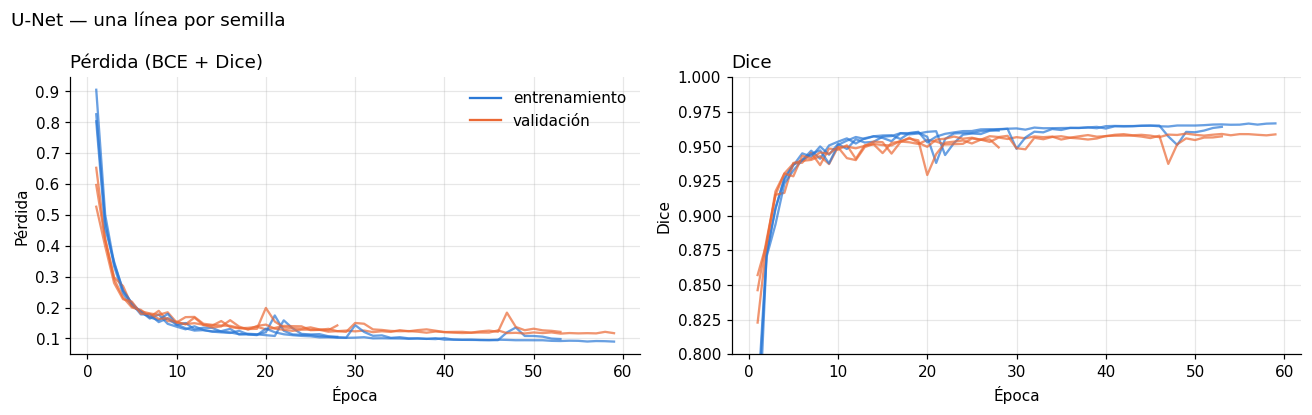

epocas  mejor_val_dice  minutos
arch seed                                 
unet 42        53           0.958    4.048
     43        28           0.955    1.950
     44        59           0.959    4.475

In [5]:
histories = pd.read_csv(SEG_RESULTS_DIR / "history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, metric, title in [(axes[0], "loss", "Pérdida (BCE + Dice)"), (axes[1], "dice", "Dice")]:
    for (arch, seed), run in histories.groupby(["arch", "seed"]):
        ax.plot(run["epoch"], run[f"train_{metric}"], color=C_TRUE, lw=1.5, alpha=0.7)
        ax.plot(run["epoch"], run[f"val_{metric}"], color=C_PRED, lw=1.5, alpha=0.7)
    ax.set_title(title, loc="left"); ax.set_xlabel("Época"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Pérdida"); axes[1].set_ylabel("Dice"); axes[1].set_ylim(0.8, 1.0)
axes[0].plot([], [], color=C_TRUE, label="entrenamiento"); axes[0].plot([], [], color=C_PRED, label="validación")
axes[0].legend(frameon=False)
fig.suptitle("U-Net — una línea por semilla", x=0.01, ha="left")
fig.tight_layout()
plt.show()

display(histories.groupby(["arch", "seed"]).agg(
    epocas=("epoch", "max"), mejor_val_dice=("val_dice", "max"), minutos=("minutes", "max")).round(3))

## 6. Calidad de la segmentación (conjunto de prueba)

El conjunto de prueba no participó en ninguna decisión: ni en el entrenamiento, ni en la detención temprana, ni en la selección de la mejor época. Por eso su Dice es una estimación honesta del desempeño sobre radiografías nuevas **del mismo tipo** (Montgomery y Shenzhen).

Dos métricas de superposición entre la máscara predicha y la manual:
- **Dice** = 2·|intersección| / (|predicha| + |real|)
- **IoU** = |intersección| / |unión|, equivalente pero más estricta.

In [6]:
metrics = pd.read_csv(SEG_RESULTS_DIR / "test_metrics.csv")
display(metrics)

summary = metrics.groupby("arch").agg(
    corridas=("seed", "count"),
    dice_medio=("test_dice", "mean"), dice_desv=("test_dice", "std"),
    iou_medio=("test_iou", "mean"), peor_imagen=("test_dice_min", "min")).round(4)
display(summary)

,arch,seed,best_epoch,epochs_run,val_dice,test_dice,test_dice_std,test_dice_min,test_iou,minutes
0,unet,42,43,53,0.9578,0.9623,0.0264,0.7922,0.9284,4.0
1,unet,43,18,28,0.9555,0.9615,0.0265,0.7958,0.9271,2.0
2,unet,44,49,59,0.9593,0.9639,0.0251,0.8095,0.9313,4.5


,corridas,dice_medio,dice_desv,iou_medio,peor_imagen
arch,,,,,
unet,3,0.9626,0.0012,0.9289,0.7922


La desviación entre semillas indica cuánto varía el resultado solo por el azar del entrenamiento. Es la referencia con la que habrá que comparar la diferencia frente a Attention U-Net: si la diferencia entre arquitecturas es menor que esta variación, no es concluyente.

count   mean    std    min
arch source                                
unet montgomery   63.0  0.976  0.015  0.908
     shenzhen    255.0  0.959  0.027  0.792

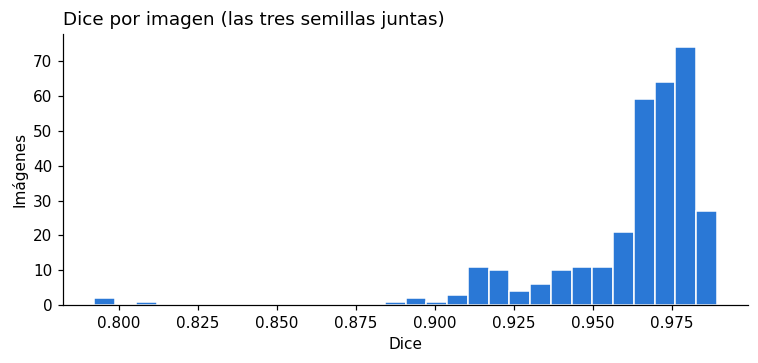

Peores casos:


,image_id,source,tb,seed,dice,iou
25,CHNCXR_0178_0,shenzhen,0,42,0.792,0.656
131,CHNCXR_0178_0,shenzhen,0,43,0.796,0.661
237,CHNCXR_0178_0,shenzhen,0,44,0.809,0.680
3,CHNCXR_0029_0,shenzhen,0,42,0.887,0.796
109,CHNCXR_0029_0,shenzhen,0,43,0.894,0.809
215,CHNCXR_0029_0,shenzhen,0,44,0.896,0.812
164,CHNCXR_0474_1,shenzhen,1,43,0.902,0.821
58,CHNCXR_0474_1,shenzhen,1,42,0.906,0.827
211,MCUCXR_0399_1,montgomery,1,43,0.908,0.832
270,CHNCXR_0474_1,shenzhen,1,44,0.910,0.835


In [7]:
per_image = pd.read_csv(SEG_RESULTS_DIR / "test_per_image.csv").merge(
    split[["image_id", "source", "tb"]], on="image_id")

display(per_image.groupby(["arch", "source"])["dice"].describe()[["count", "mean", "std", "min"]].round(3))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(per_image["dice"], bins=30, color=C_TRUE, edgecolor="white")
ax.set_title("Dice por imagen (las tres semillas juntas)", loc="left")
ax.set_xlabel("Dice"); ax.set_ylabel("Imágenes")
fig.tight_layout()
plt.show()

print("Peores casos:")
display(per_image.sort_values("dice").head(10)[["image_id", "source", "tb", "seed", "dice", "iou"]].round(3))

Los casos difíciles son los informativos. **Los mismos identificadores aparecen con las tres semillas**, así que no son fallos aleatorios del entrenamiento: son radiografías difíciles o con máscaras manuales discutibles. Conviene mirarlas antes de dar por buena la referencia.

## 7. Siguientes pasos (pendientes)

Esta etapa cierra con U-Net entrenada y evaluada. Lo que sigue, en orden:

In [ ]:
# 1: entrenar Attention U-Net con la misma rutina y comparar con U-Net
# 2: generar las máscaras de las 1600 imágenes de TBX11K (predict.py)
# 3: integrar MedSAM al registro de métodos